In [1]:
import numpy as np
import pyoti.sparse as oti
import itertools
from wddegp.wddegp import wddegp
import utils
from matplotlib import pyplot as plt

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 2
n_bases = 2
num_pts_per_axis = 5
domain_bounds = ((-1, 1), (-1, 1))
test_grid_resolution = 50
normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
n_restarts = 15
swarm_size = 100
random_seed = 0
np.random.seed(random_seed)

# Submodel groups (initial and sequential)
submodel_groups_initial = [
    [1, 2, 3], [5, 10, 15], [9, 14, 19], [21, 22, 23],
    [0], [4], [20], [24],
    [6, 7, 8, 11, 12, 13, 16, 17, 18]
]

# Ray angles per submodel
submodel_ray_thetas = [
    [-np.pi/4, 0, np.pi/4], [-np.pi/4, 0, np.pi/4], [-np.pi/4, 0, np.pi/4],
    [-np.pi/4, 0, np.pi/4], [-np.pi/2, 0, -np.pi/4], [np.pi/2, 0, np.pi/4],
    [np.pi/2, 0, np.pi/4], [-np.pi/2, 0, -np.pi/4], [np.pi/2, np.pi/4, np.pi/4 + np.pi/2]
]

# Derivative indices (example, same for all)
submodel_der_indices = [
    [[[[1,1]], [[1,2]], [[2,1]], [[2,2]], [[3,1]], [[3,2]]]] for _ in range(len(submodel_groups_initial))
]

In [3]:
def true_function(X, alg=np):
    x1, x2 = X[:,0], X[:,1]
    return ((4 - 2.1*x1**2 + (x1**4)/3.0) * x1**2 + x1*x2 + (-4 + 4*x2**2) * x2**2)

In [4]:
def generate_training_data():
    # 1. Create initial grid and reorder sequentially
    x_vals = np.linspace(domain_bounds[0][0], domain_bounds[0][1], num_pts_per_axis)
    y_vals = np.linspace(domain_bounds[1][0], domain_bounds[1][1], num_pts_per_axis)
    X_initial = np.array(list(itertools.product(x_vals, y_vals)))

    # Reorder training points to sequential GP input
    sequential_groups = []
    current_pos = 0
    for group in submodel_groups_initial:
        sequential_groups.append(list(range(current_pos, current_pos + len(group))))
        current_pos += len(group)

    old_flat = list(itertools.chain.from_iterable(submodel_groups_initial))
    new_flat = list(itertools.chain.from_iterable(sequential_groups))
    reorder_map = np.zeros(len(old_flat), dtype=int)
    for i in range(len(old_flat)):
        reorder_map[new_flat[i]] = old_flat[i]

    X_train = X_initial[reorder_map]

    # 2. Create per-submodel data
    y_train_data_all = []
    rays_data_all = []
    y_func_values = true_function(X_train, alg=np)

    for k, group_indices in enumerate(sequential_groups):
        X_sub = X_train[group_indices]
        X_pert = oti.array(X_sub)

        # Rays for this submodel
        thetas = submodel_ray_thetas[k]
        rays = np.column_stack([[np.cos(t), np.sin(t)] for t in thetas])
        rays_data_all.append(rays)

        # Apply perturbations using hypercomplex bases
        e_bases = [oti.e(i+1, order=n_order) for i in range(len(thetas))]
        perts = np.dot(rays, e_bases)
        for j in range(n_bases):
            X_pert[:, j] += perts[j]

        # Evaluate function and derivatives
        y_hc = true_function(X_pert, alg=oti)
        for comb in itertools.combinations(range(1, len(thetas)+1), 2):
            y_hc = y_hc.truncate(comb)

        # Collect derivatives
        y_train_submodel = [y_func_values]
        der_indices_submodel = submodel_der_indices[k]
        for group in der_indices_submodel:
            for sub_group in group:
                y_train_submodel.append(y_hc.get_deriv(sub_group).reshape(-1,1))

        y_train_data_all.append(y_train_submodel)

    return X_train, sequential_groups, y_train_data_all, rays_data_all

In [5]:
def train_model(X_train, submodel_indices, y_train_data_all, rays_data_all):
    gp_model = wddegp(
        X_train, y_train_data_all, n_order, n_bases,
        submodel_indices, submodel_der_indices, rays_data_all,
        normalize=normalize_data, kernel=kernel, kernel_type=kernel_type
    )
    params = gp_model.optimize_hyperparameters(
    optimizer='jade',
    pop_size = 100,
    n_generations = 15,
    local_opt_every = None,
    debug = True
    )
    return gp_model, params

In [6]:
def evaluate_model(gp_model, params, X_train):
    x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
    y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
    X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
    X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

    y_pred, _ = gp_model.predict(X_test, params, calc_cov=False, return_submodels=True)
    y_true = true_function(X_test, alg=np)
    nrmse_val = utils.nrmse(y_true, y_pred)
    return {'X_test': X_test, 'X1_grid': X1_grid, 'X2_grid': X2_grid,
            'y_pred': y_pred, 'y_true': y_true, 'nrmse': nrmse_val, 'X_train': X_train}

In [7]:
def visualize_results(results):
    X_train = results['X_train']
    y_true_grid = results['y_true'].reshape(results['X1_grid'].shape)
    y_pred_grid = results['y_pred'].reshape(results['X1_grid'].shape)
    abs_error_grid = np.abs(y_true_grid - y_pred_grid)

    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    c1 = axes[0].contourf(results['X1_grid'], results['X2_grid'], y_pred_grid, levels=50, cmap="viridis")
    axes[0].scatter(X_train[:,0], X_train[:,1], c="red", edgecolor="k", s=50)
    axes[0].set_title("GP Prediction")
    fig.colorbar(c1, ax=axes[0])

    c2 = axes[1].contourf(results['X1_grid'], results['X2_grid'], y_true_grid, levels=50, cmap="viridis")
    axes[1].scatter(X_train[:,0], X_train[:,1], c="red", edgecolor="k", s=50)
    axes[1].set_title("True Function")
    fig.colorbar(c2, ax=axes[1])

    c3 = axes[2].contourf(results['X1_grid'], results['X2_grid'], abs_error_grid, levels=50, cmap="magma")
    axes[2].scatter(X_train[:,0], X_train[:,1], c="red", edgecolor="k", s=50)
    axes[2].set_title("Absolute Error")
    fig.colorbar(c3, ax=axes[2])

    for ax in axes:
        ax.set(xlabel="x₁", ylabel="x₂")
    plt.tight_layout()
    plt.show()

Gen 1: best f=434.0657559099702


Gen 2: best f=434.0657559099702


Gen 3: best f=434.0657559099702


Gen 4: best f=421.7935115978095


Gen 5: best f=421.7935115978095


...

Gen 11: best f=157.93790507817073


Gen 12: best f=157.93790507817073


Gen 13: best f=157.93790507817073


Gen 14: best f=157.93790507817073


Gen 15: best f=62.77121157999663


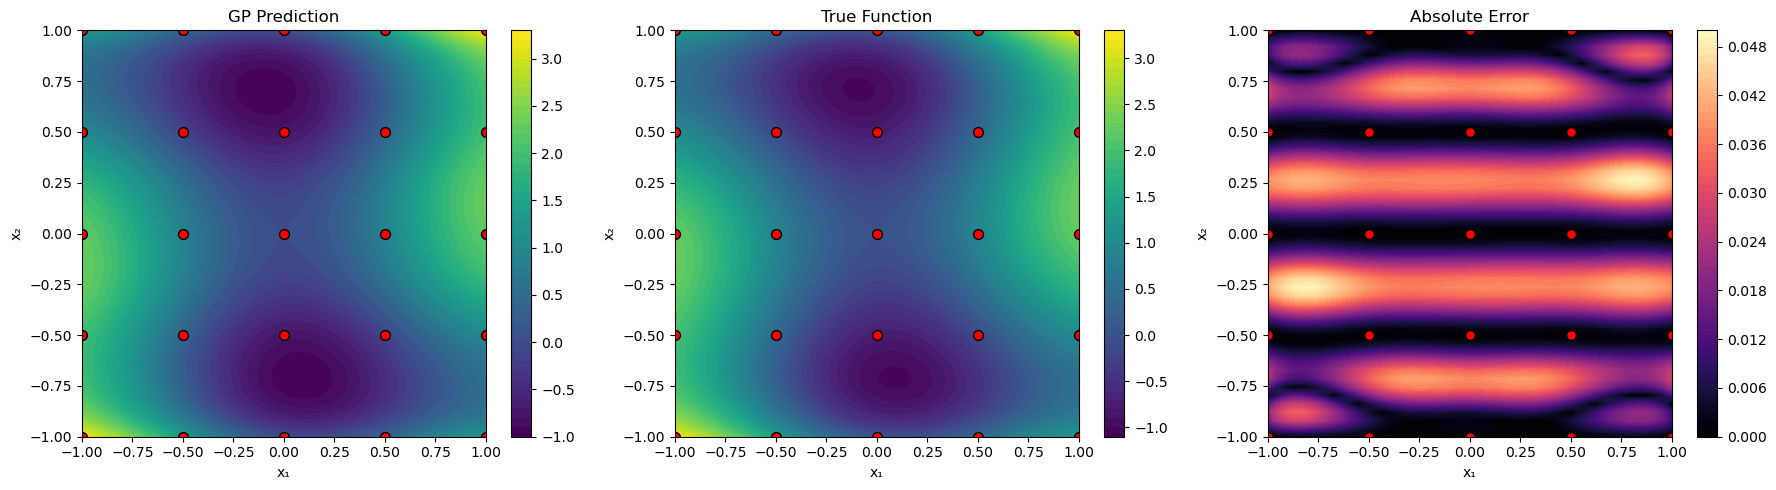

Final NRMSE: 0.005103


In [8]:
X_train, submodel_indices, y_train_data_all, rays_data_all = generate_training_data()
gp_model, params = train_model(X_train, submodel_indices, y_train_data_all, rays_data_all)
results = evaluate_model(gp_model, params, X_train)
visualize_results(results)
print(f"Final NRMSE: {results['nrmse']:.6f}")